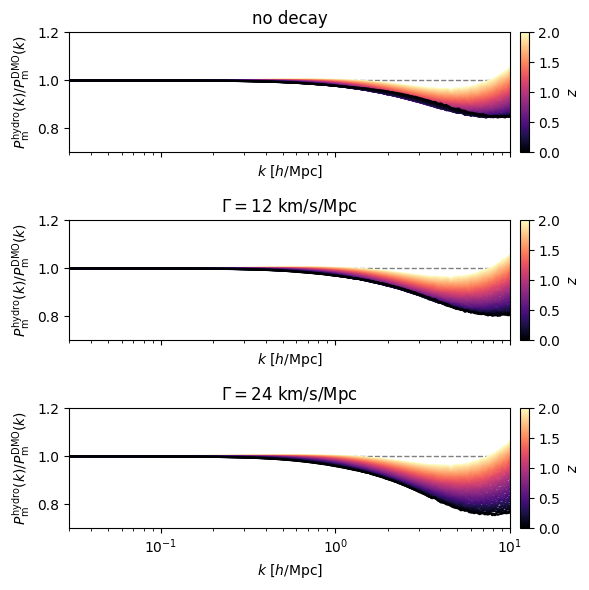

In [3]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm, colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

zs = np.linspace(2, 0, 41)

h = 0.6732 # same for all three simulations (the Planck value)

fig, ax = plt.subplots(3, 1, sharex = True, figsize=(6, 6))

for z in zs:
    # Load the data
    z_str = "%dp%02d" % (int(z), int(round(z,2)*100-int(z)*100))
    data = np.loadtxt("power_z%s.txt" % z_str)
    
    # Unpack the data
    k = data[:,0] # 1/Mpc
    kh = data[:,0] / h
    S_no_decay = data[:,4]/data[:,1]
    S_decay_12 = data[:,5]/data[:,2]
    S_decay_24 = data[:,6]/data[:,3]
    
    # Remove point affected by artefact due to folding
    select = np.ones(len(k), dtype=bool)
    select[129] = False
    
    # Plot the data
    ax[0].semilogx(kh[select], S_no_decay[select], c = cm.magma(z / 2))
    ax[1].semilogx(kh[select], S_decay_12[select], c = cm.magma(z / 2))
    ax[2].semilogx(kh[select], S_decay_24[select], c = cm.magma(z / 2))

labels = ['no decay', r'$\Gamma = 12$ km/s/Mpc', r'$\Gamma = 24$ km/s/Mpc']

for i in range(3):
    # Configure the axes
    ax[i].plot([1e-3, 1e1], [1, 1], c = 'gray', ls = '--', lw = 1, zorder=-10)
    ax[i].set_title(labels[i])
    ax[i].set_xlabel(r'$k$ [$h/\mathrm{Mpc}$]')
    ax[i].set_ylabel(r'$P^\mathrm{hydro}_\mathrm{m}(k)/P^\mathrm{DMO}_\mathrm{m}(k)$')
    ax[i].set_ylim((0.7, 1.2))
    ax[i].set_xlim((3e-2, 10))
    
    # Add color bar
    norm = colors.Normalize(vmin=0, vmax=2)
    sm = cm.ScalarMappable(cmap=cm.magma, norm=norm)
    sm.set_array([])
    divider = make_axes_locatable(ax[i])
    cax = divider.append_axes("right", size="2%", pad=0.1)
    cbar = fig.colorbar(sm, ax=ax[i], cax=cax)
    cbar.set_label(r'$z$')

plt.tight_layout()
plt.show()